# Milestone 1,2 – Data Preparation & Initial Analysis
This notebook performs data loading, inspection, cleaning, anomaly removal, feature engineering, aggregation, and saving processed datasets.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv('/Users/garikapatiaishwarya/.Trash/climatescope/data/raw/GlobalWeatherRepository.csv')
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
# Inspect structure
df.shape, df.columns, df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122771 entries, 0 to 122770
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       122771 non-null  object 
 1   location_name                 122771 non-null  object 
 2   latitude                      122771 non-null  float64
 3   longitude                     122771 non-null  float64
 4   timezone                      122771 non-null  object 
 5   last_updated_epoch            122771 non-null  int64  
 6   last_updated                  122771 non-null  object 
 7   temperature_celsius           122771 non-null  float64
 8   temperature_fahrenheit        122771 non-null  float64
 9   condition_text                122771 non-null  object 
 10  wind_mph                      122771 non-null  float64
 11  wind_kph                      122771 non-null  float64
 12  wind_degree                   122771 non-nul

((122771, 41),
 Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
        'last_updated_epoch', 'last_updated', 'temperature_celsius',
        'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
        'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
        'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
        'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
        'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
        'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
        'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
        'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
        'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
       dtype='object'),
 None,
             latitude      longitude  last_updated_epoch  temperature_celsius  \
 count  122771.000000  122771.000000        1.227710e+05        122

In [4]:
# Convert datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['last_updated'].head()

0   2024-05-16 13:15:00
1   2024-05-16 10:45:00
2   2024-05-16 09:45:00
3   2024-05-16 10:45:00
4   2024-05-16 09:45:00
Name: last_updated, dtype: datetime64[ns]

In [5]:
# Missing values summary
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_percent': missing_percent})
missing_summary.sort_values(by='missing_percent', ascending=False)

,missing_count,missing_percent
country,0,0.0
feels_like_fahrenheit,0,0.0
visibility_miles,0,0.0
uv_index,0,0.0
gust_mph,0,0.0
gust_kph,0,0.0
air_quality_Carbon_Monoxide,0,0.0
air_quality_Ozone,0,0.0
air_quality_Nitrogen_dioxide,0,0.0
air_quality_Sulphur_dioxide,0,0.0


In [6]:
# Handle missing values (drop critical nulls)
df_cleaned_nulls = df.dropna(subset=[
    'temperature_celsius','humidity','precip_mm','wind_kph','uv_index','last_updated','country'
])
df_cleaned_nulls.shape

(122771, 41)

In [7]:
# Remove unrealistic anomalies
df_cleaned_nulls = df_cleaned_nulls[
    (df_cleaned_nulls['temperature_celsius'].between(-50, 60)) &
    (df_cleaned_nulls['precip_mm'] >= 0) &
    (df_cleaned_nulls['wind_kph'] <= 200)
]
df_cleaned_nulls.shape

(122767, 41)

In [8]:
# Standardize country names
df_cleaned_nulls['country'] = df_cleaned_nulls['country'].str.strip().str.title()

In [9]:
# Select relevant columns
df_clean = df_cleaned_nulls[[
    'country','location_name','latitude','longitude','last_updated',
    'temperature_celsius','humidity','precip_mm','wind_kph','condition_text','uv_index'
]]

In [10]:
# Feature engineering
df_clean['year'] = df_clean['last_updated'].dt.year
df_clean['month'] = df_clean['last_updated'].dt.month
df_clean['month_name'] = df_clean['last_updated'].dt.month_name()

/var/folders/7r/nnw19j455kg51qz7l_k8w_4r0000gn/T/ipykernel_3230/1991845906.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['year'] = df_clean['last_updated'].dt.year
/var/folders/7r/nnw19j455kg51qz7l_k8w_4r0000gn/T/ipykernel_3230/1991845906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['month'] = df_clean['last_updated'].dt.month
/var/folders/7r/nnw19j455kg51qz7l_k8w_4r0000gn/T/ipykernel_3230/1991845906.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [11]:
# Data coverage analysis
date_range = (df_clean['last_updated'].min(), df_clean['last_updated'].max())
num_countries = df_clean['country'].nunique()
records_per_country = df_clean['country'].value_counts().head()
date_range, num_countries, records_per_country

((Timestamp('2024-05-16 01:45:00'), Timestamp('2026-02-07 19:45:00')),
 211,
 country
 Bulgaria     1444
 Indonesia    1263
 Sudan        1260
 Turkey       1259
 Thailand     1259
 Name: count, dtype: int64)

In [12]:
# Monthly aggregation
monthly_df = df_clean.groupby(['country','year','month'], as_index=False).agg({
    'temperature_celsius': 'mean',
    'humidity': 'mean',
    'precip_mm': 'sum',
    'wind_kph': 'mean',
    'uv_index': 'mean'
})
monthly_df.head()

,country,year,month,temperature_celsius,humidity,precip_mm,wind_kph,uv_index
0,Afghanistan,2024,5,20.305882,38.058824,1.85,11.517647,3.764706
1,Afghanistan,2024,6,25.590000,24.833333,2.18,17.110000,6.500000
2,Afghanistan,2024,7,31.303448,17.931034,0.01,20.731034,7.758621
3,Afghanistan,2024,8,30.848387,20.548387,1.15,20.196774,7.483871
4,Afghanistan,2024,9,28.216667,13.733333,0.43,12.223333,7.000000


In [15]:
# Save cleaned daily dataset
df_clean.to_csv('/Users/garikapatiaishwarya/.Trash/climatescope/data/processed/global_weather_cleaned_daily.csv', index=False)

# Save aggregated monthly dataset
monthly_df.to_csv('/Users/garikapatiaishwarya/.Trash/climatescope/data/processed/global_weather_cleaned_monthly.csv', index=False)

In [ ]:
# mile stone 2

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

# Use datasets already created in Milestone 1
daily_df = df_clean.copy()        # cleaned daily data
monthly_df = monthly_df.copy()    # monthly aggregated data



Statistical Summary:
            latitude      longitude                   last_updated  \
count  122767.000000  122767.000000                         122767   
mean       19.191495      21.996774  2025-03-28 15:28:33.260078080   
min       -41.300000    -175.200000            2024-05-16 01:45:00   
25%         3.750000      -6.836100            2024-10-22 05:15:00   
50%        17.250000      23.316700            2025-03-28 22:45:00   
75%        40.400000      50.580000            2025-09-02 10:15:00   
max        64.150000     179.220000            2026-02-07 19:45:00   
std        24.427842      65.792932                            NaN   

       temperature_celsius       humidity      precip_mm       wind_kph  \
count        122767.000000  122767.000000  122767.000000  122767.000000   
mean             21.693114      66.021390       0.137340      12.972792   
min             -29.800000       2.000000       0.000000       3.600000   
25%              16.300000      50.000000       

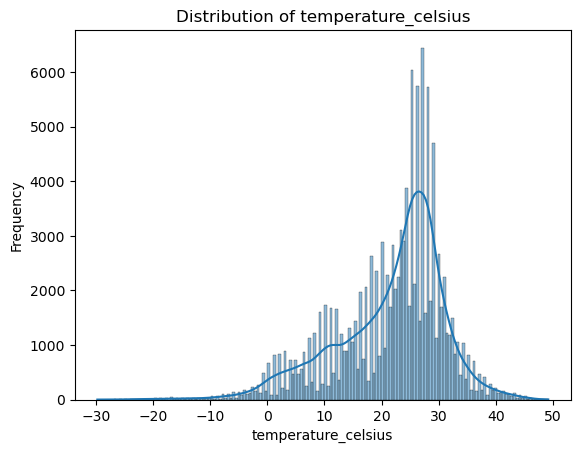

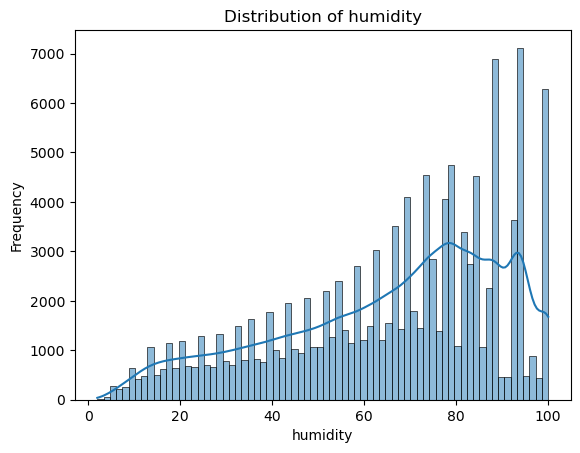

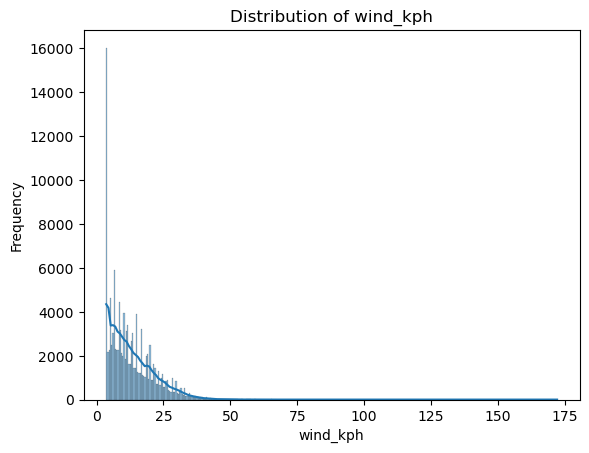

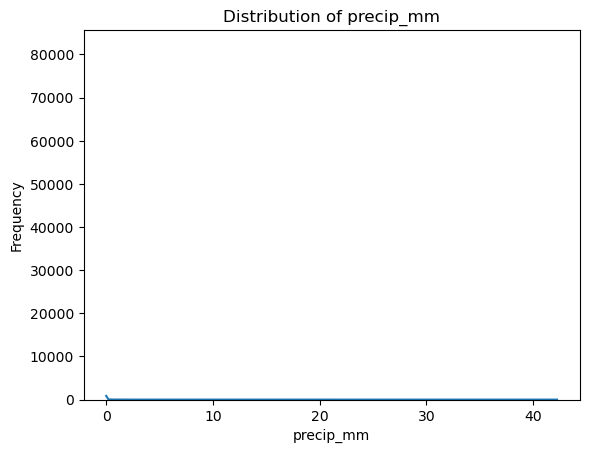

In [19]:

# --------------------------------
# 1. Statistical Distribution
# --------------------------------
print("Statistical Summary:")
print(daily_df.describe())

numeric_cols = ["temperature_celsius", "humidity", "wind_kph", "precip_mm"]

for col in numeric_cols:
    plt.figure()
    sns.histplot(daily_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

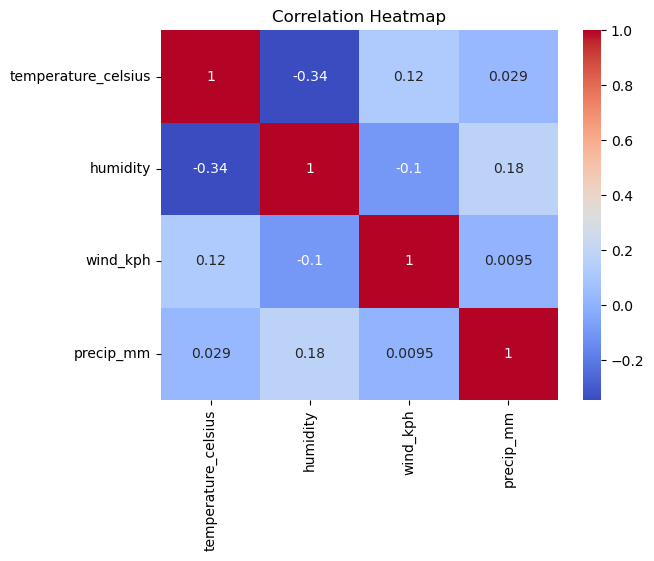

In [20]:

# --------------------------------
# 2. Correlation Analysis
# --------------------------------
plt.figure()
corr = daily_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


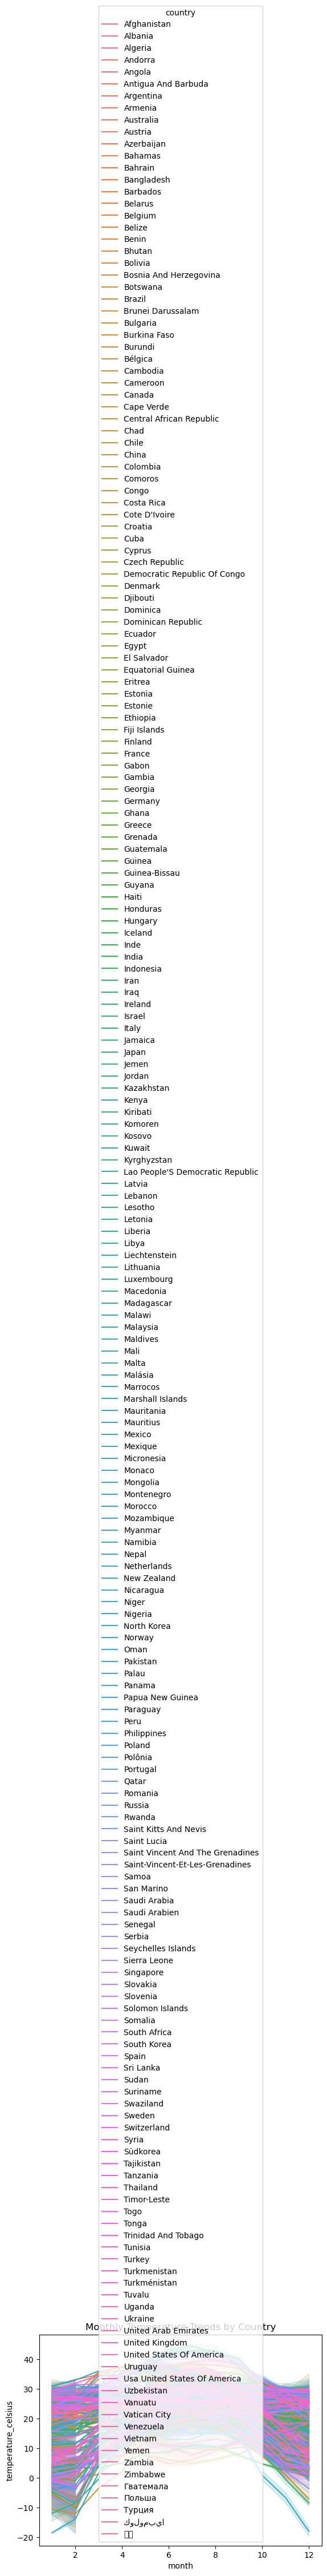

In [21]:

# --------------------------------
# 3. Seasonal Trends
# --------------------------------
plt.figure()
sns.lineplot(data=monthly_df, x="month", y="temperature_celsius", hue="country")
plt.title("Monthly Temperature Trends by Country")
plt.show()


Extreme Weather Events Count: 2484


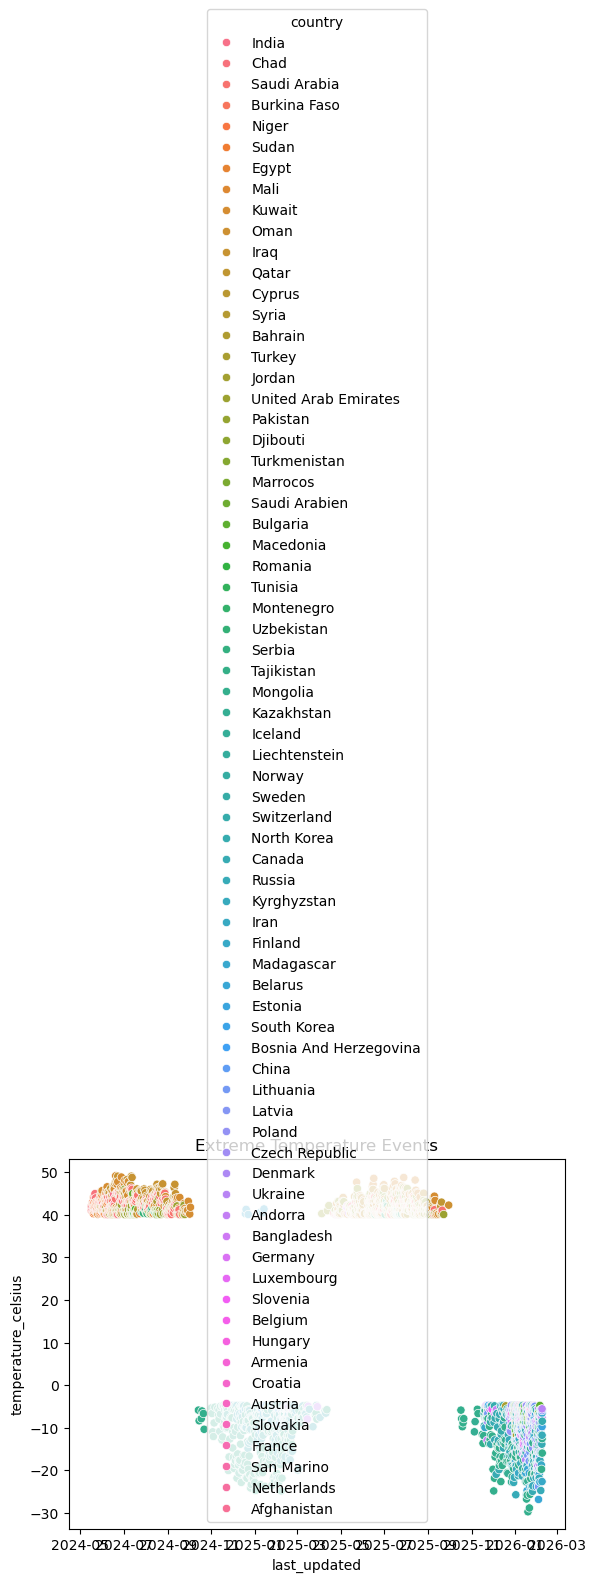

In [22]:

# --------------------------------
# 4. Extreme Weather Detection
# --------------------------------
high_temp = daily_df["temperature_celsius"].quantile(0.99)
low_temp = daily_df["temperature_celsius"].quantile(0.01)

extreme_events = daily_df[
    (daily_df["temperature_celsius"] >= high_temp) |
    (daily_df["temperature_celsius"] <= low_temp)
]

print("Extreme Weather Events Count:", len(extreme_events))

plt.figure()
sns.scatterplot(data=extreme_events, x="last_updated", y="temperature_celsius", hue="country")
plt.title("Extreme Temperature Events")
plt.show()



/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 40481 (\N{CJK UNIFIED IDEOGRAPH-9E21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


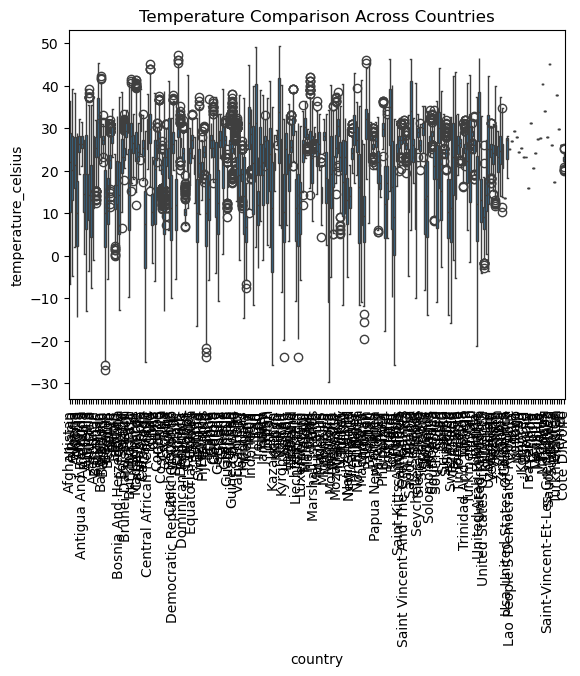

In [24]:
# --------------------------------
# 5. Regional Comparison
# --------------------------------
plt.figure()
sns.boxplot(data=daily_df, x="country", y="temperature_celsius")
plt.xticks(rotation=90)
plt.title("Temperature Comparison Across Countries")
plt.show()


